Loading the dataset in the jupyter notebook using python pandas

In [1]:
import pandas as pd


df = pd.read_csv("E:\\archive\\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


Checking the shape of the dataset, this shows the number of rows and columns

In [2]:
df.shape

(7043, 21)

## Q1: Checking the information of the dataset
This gives the concise summary of the Dataset, including the no. of rows, columns, non-null values, datatypes and memory usage

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


This gives the mean, min, max etc of the dataset

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Q2: Convert TotalCharges to Numeric
TotalCharges is stored as text due to blank values in some rows. We convert it
to numeric using errors='coerce', which turns invalid entries into NaN, then
inspect those rows.

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(df['TotalCharges'].isnull().sum())
print(df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

11
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN


## Q3: Handle Missing TotalCharges Values
All NaN rows have tenure = 0, meaning they're new customers with no billing
history yet. We fill these with 0 instead of dropping them.

In [8]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(df['TotalCharges'].isnull().sum())

0


## Q4: Check for Duplicate Customer IDs
We verify there are no duplicate customerID`s or fully duplicated rows before
running any aggregations.

In [9]:
print(df['customerID'].duplicated().sum())
print(df.duplicated().sum())

0
0


## Q5: Convert SeniorCitizen from 0/1 to Yes/No
SeniorCitizen uses 0/1 while other categorical columns use Yes/No. We map it
for consistency across the dataset.

In [10]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print(df['SeniorCitizen'].value_counts())

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64


## Q6: Decide on customerID Column
customerID has no analytical value but is kept for traceability. It will be
excluded from analysis/modeling later, not dropped now.

In [11]:
print(df['customerID'].nunique(), "unique customer IDs out of", len(df), "rows")

7043 unique customer IDs out of 7043 rows


## Q7: Overall Churn Rate
We calculate the percentage of customers who churned vs stayed using
value_counts with normalize=True to get proportions instead of raw counts.

In [12]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


## Q8: Churn Rate by Contract Type
We group customers by Contract type and calculate what percentage in each
group churned, to see if contract length affects retention.

In [13]:
churn_by_contract = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
print(churn_by_contract)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


## Q9: Churn Rate by Internet Service
Similarly, we group by InternetService type to see whether DSL, Fiber optic,
or No internet customers churn at different rates.

In [14]:
churn_by_internet = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack() * 100
print(churn_by_internet)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


## Q10: Average Tenure and Monthly Charges by Churn
We compare the average tenure and MonthlyCharges between churned and
non-churned customers to spot behavioral differences.

In [15]:
avg_by_churn = df.groupby('Churn')[['tenure', 'MonthlyCharges']].mean()
print(avg_by_churn)

          tenure  MonthlyCharges
Churn                           
No     37.569965       61.265124
Yes    17.979133       74.441332


## Q11: Churn Rate by Payment Method
We check if certain payment methods, like electronic check vs automatic
bank transfer, are linked to higher churn.

In [16]:
churn_by_payment = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack() * 100
print(churn_by_payment)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


## Q12: Churn Rate by Partner and Dependents
We check separately whether having a partner or having dependents is
associated with lower churn, since family ties may increase loyalty.

In [17]:
churn_by_partner = df.groupby('Partner')['Churn'].value_counts(normalize=True).unstack() * 100
print(churn_by_partner)

churn_by_dependents = df.groupby('Dependents')['Churn'].value_counts(normalize=True).unstack() * 100
print(churn_by_dependents)

Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903
Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237


## Q13: Churn Rate by Senior Citizen Status
We check if senior citizens churn at a different rate compared to
non-senior customers.

In [18]:
churn_by_senior = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack() * 100
print(churn_by_senior)

Churn                 No        Yes
SeniorCitizen                      
No             76.393832  23.606168
Yes            58.318739  41.681261


## Q14: Churn Rate by Tenure Buckets
We bucket tenure into ranges like new, mid-term, and long-term customers,
then check if newer customers churn more than long-term ones.

In [19]:
bins = [0, 12, 24, 48, 72]
labels = ['0-12 months', '13-24 months', '25-48 months', '49-72 months']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

churn_by_tenure = df.groupby('tenure_group', observed=True)['Churn'].value_counts(normalize=True).unstack() * 100
print(churn_by_tenure)

Churn                No        Yes
tenure_group                      
0-12 months   52.561757  47.438243
13-24 months  71.289062  28.710938
25-48 months  79.611041  20.388959
49-72 months  90.486824   9.513176


## Q15: Churn Rate by Contract Type
We visualize the churn percentage across each Contract type using a bar
chart, making it easy to spot which contract type has the highest churn.

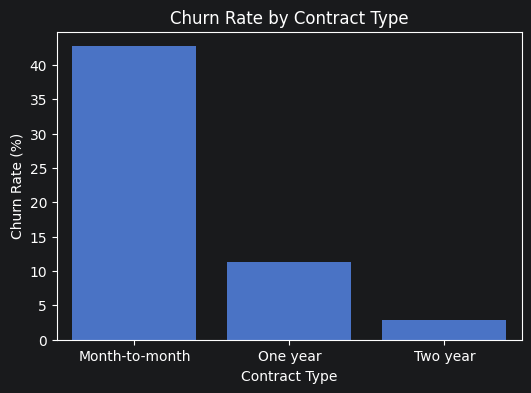

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(x=churn_by_contract.index, y=churn_by_contract['Yes'])
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
plt.show()

## Q16: Churn Rate by Internet Service
We plot churn percentage by InternetService type to see if Fiber optic
users churn more than DSL or No internet users.

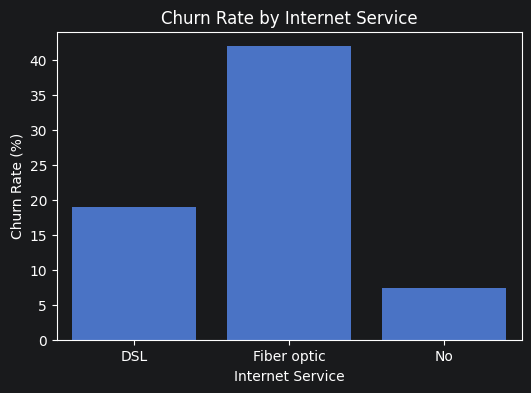

In [21]:
plt.figure(figsize=(6,4))
sns.barplot(x=churn_by_internet.index, y=churn_by_internet['Yes'])
plt.title('Churn Rate by Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Internet Service')
plt.show()

## Q17: Tenure Distribution by Churn
We compare how tenure is distributed for churned vs retained customers
using an overlaid histogram with a KDE curve, to see if churn clusters
around new customers.

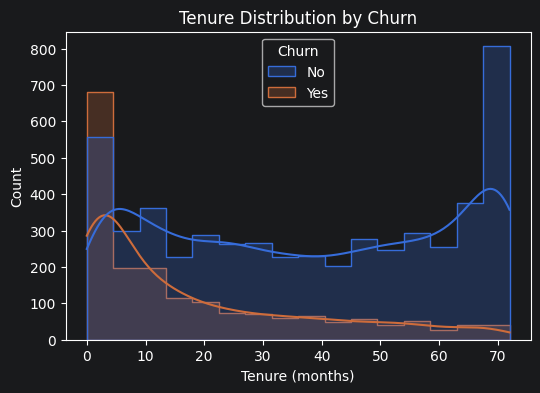

In [22]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, element='step')
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.show()

## Q18: Monthly Charges by Churn
We use a box plot to compare the spread and median of MonthlyCharges
between churned and non-churned customers.

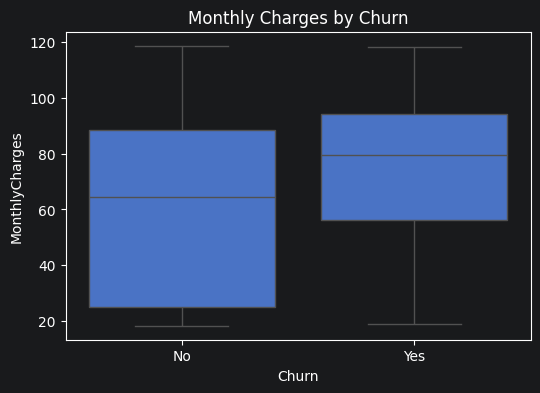

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges by Churn')
plt.show()

## Q19: Churn Rate by Payment Method
We visualize churn percentage across payment methods to check if
electronic check users churn more than other payment types.

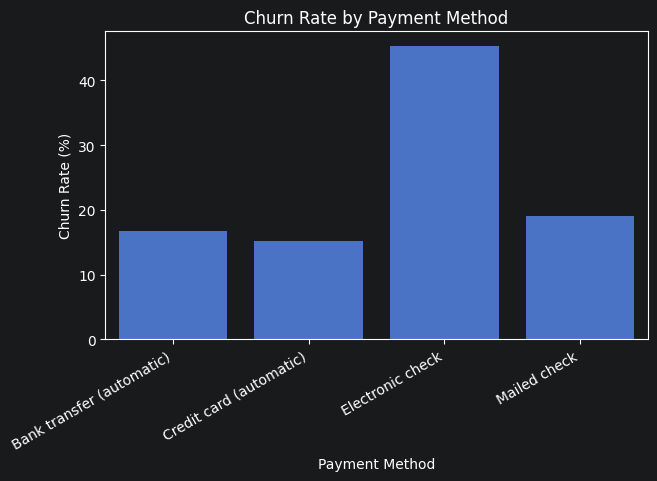

In [24]:
plt.figure(figsize=(7,4))
sns.barplot(x=churn_by_payment.index, y=churn_by_payment['Yes'])
plt.title('Churn Rate by Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Payment Method')
plt.xticks(rotation=30, ha='right')
plt.show()

## Q20: Correlation Heatmap
We encode Churn as 0/1 and check how tenure, MonthlyCharges, and
TotalCharges correlate with churn, using a heatmap for a quick visual
summary.

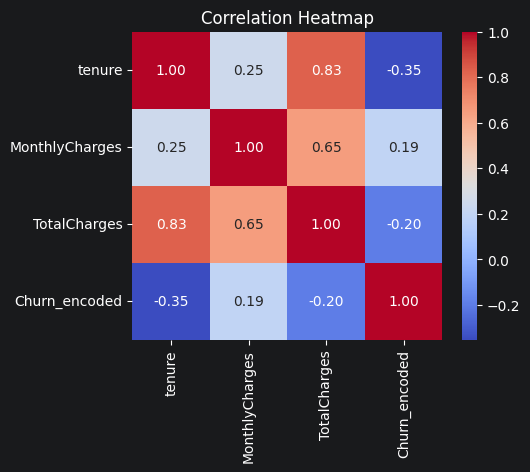

In [25]:
df['Churn_encoded'] = df['Churn'].map({'No': 0, 'Yes': 1})

corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_encoded']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Now saving our cleaned dataset

In [27]:
df.to_csv('E:\\archive\\telco_churn_cleaned.csv', index=False)

## Load Cleaned Data into Mysql
Now we are using sqlalchemy to create a connection and get our dataset into mysql for our further analysis

In [ ]:
from sqlalchemy import create_engine
import pandas as pd

username = "root"
password = "Raviroshan2002"
host = "localhost"
port = "3306"
database = "Teleco_Churn"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

table_name = "Customers"
df.to_sql(table_name, engine, if_exists='replace', index=False)

result = pd.read_sql(f"SELECT * FROM {table_name} LIMIT 5", engine)
print(result) 